# Transfer Learning Using MobileNetV2

This notebook implements an improved steel surface defect classification model using transfer learning. A pretrained MobileNetV2 model will be adapted and trained using the prepared NEU surface defect dataset.

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
GPU name: Tesla T4


Import the required libraries

In [ ]:
import os
import copy
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


Set a random seed

In [ ]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("Random seed set to:", RANDOM_SEED)

Random seed set to: 42


Define the computing device

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device being used:", device)

Device being used: cuda


Locate the shared project folder

In [ ]:
MY_DRIVE = Path("/content/drive/MyDrive")

print("Folders inside My Drive:")

for item in MY_DRIVE.iterdir():
    if item.is_dir():
        print(item.name)

Folders inside My Drive:
Colab Notebooks
e23-co5430-Surface-Defect-Detection


Define the project path

In [ ]:
PROJECT_DIR = Path(
    "/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection"
)

print("Project path:", PROJECT_DIR)
print("Project folder exists:", PROJECT_DIR.exists())

Project path: /content/drive/MyDrive/e23-co5430-Surface-Defect-Detection
Project folder exists: True


Inspect the project structure

In [ ]:
for root, directories, files in os.walk(PROJECT_DIR):
    level = str(root).replace(str(PROJECT_DIR), "").count(os.sep)

    if level > 3:
        continue

    indent = "    " * level
    print(f"{indent}{Path(root).name}/")

    for file_name in files[:5]:
        print(f"{indent}    {file_name}")

e23-co5430-Surface-Defect-Detection/
    README.md
    notebooks/
        03_transfer_learning.ipynb
        01_dataset_preparation.ipynb
        02_baseline_cnn.ipynb
        04_evaluation.ipynb
    data/
        raw/
            crazing/
                crazing_107.jpg
                crazing_114.jpg
                crazing_120.jpg
                crazing_10.jpg
                crazing_104.jpg
            inclusion/
                inclusion_158.jpg
                inclusion_108.jpg
                inclusion_119.jpg
                inclusion_145.jpg
                inclusion_151.jpg
            patches/
                patches_111.jpg
                patches_12.jpg
                patches_134.jpg
                patches_141.jpg
                patches_13.jpg
            pitted_surface/
                pitted_surface_1.jpg
                pitted_surface_101.jpg
                pitted_surface_10.jpg
                pitted_surface_106.jpg
                pitted_surface_100.jpg
         

Define the dataset paths

In [ ]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection"
)

RAW_DIR = PROJECT_DIR / "data" / "raw"
TRAIN_DIR = PROJECT_DIR / "data" / "split" / "train"
VALIDATION_DIR = PROJECT_DIR / "data" / "split" / "validation"
TEST_DIR = PROJECT_DIR / "data" / "split" / "test"

MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"

Verify all paths

In [ ]:
print("Raw folder exists:", RAW_DIR.exists())
print("Training folder exists:", TRAIN_DIR.exists())
print("Validation folder exists:", VALIDATION_DIR.exists())
print("Test folder exists:", TEST_DIR.exists())

Raw folder exists: True
Training folder exists: True
Validation folder exists: True
Test folder exists: True


Display the class folders

In [ ]:
def show_folder_contents(folder_path):
    print(f"\nContents of: {folder_path}")

    if not folder_path.exists():
        print("Folder does not exist.")
        return

    items = list(folder_path.iterdir())

    if len(items) == 0:
        print("Folder is empty.")
        return

    for item in sorted(items):
        print(item.name)


show_folder_contents(TRAIN_DIR)
show_folder_contents(VALIDATION_DIR)
show_folder_contents(TEST_DIR)


Contents of: /content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/data/split/train
Folder is empty.

Contents of: /content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/data/split/validation
Folder is empty.

Contents of: /content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/data/split/test
Folder is empty.


Confirm the raw image counts

In [ ]:
from pathlib import Path

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

def count_images_by_class(directory):
    counts = {}

    for class_folder in sorted(directory.iterdir()):
        if class_folder.is_dir():
            count = sum(
                1
                for file in class_folder.iterdir()
                if file.suffix.lower() in IMAGE_EXTENSIONS
            )
            counts[class_folder.name] = count

    return counts


raw_counts = count_images_by_class(RAW_DIR)

print("Raw image counts:")

for class_name, count in raw_counts.items():
    print(f"{class_name}: {count}")

print("Total images:", sum(raw_counts.values()))

Raw image counts:
crazing: 300
inclusion: 300
patches: 300
pitted_surface: 300
rolled_in_scale: 300
scratches: 300
Total images: 1800


Clear the empty split folders

In [ ]:
SPLIT_DIR = PROJECT_DIR / "data" / "split"

In [ ]:
import shutil

if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)

SPLIT_DIR.mkdir(parents=True, exist_ok=True)

print("Old split folder removed and recreated.")

Old split folder removed and recreated.


Create a fixed 70/15/15 split

In [ ]:
RANDOM_SEED = 42

TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15

random.seed(RANDOM_SEED)

split_summary = []

for class_folder in sorted(RAW_DIR.iterdir()):

    if not class_folder.is_dir():
        continue

    class_name = class_folder.name

    image_files = [
        file
        for file in class_folder.iterdir()
        if file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    random.Random(RANDOM_SEED).shuffle(image_files)

    total_images = len(image_files)

    train_end = int(total_images * TRAIN_RATIO)

    validation_end = train_end + int(
        total_images * VALIDATION_RATIO
    )

    train_images = image_files[:train_end]

    validation_images = image_files[
        train_end:validation_end
    ]

    test_images = image_files[validation_end:]

    split_groups = {
        "train": train_images,
        "validation": validation_images,
        "test": test_images
    }

    for split_name, selected_images in split_groups.items():

        destination_folder = (
            SPLIT_DIR / split_name / class_name
        )

        destination_folder.mkdir(
            parents=True,
            exist_ok=True
        )

        for image_path in selected_images:
            shutil.copy2(
                image_path,
                destination_folder / image_path.name
            )

    split_summary.append({
        "class": class_name,
        "train": len(train_images),
        "validation": len(validation_images),
        "test": len(test_images),
        "total": total_images
    })

print("Dataset split completed.")

Dataset split completed.


Display the split summary

In [ ]:
split_df = pd.DataFrame(split_summary)

display(split_df)

,class,train,validation,test,total
0,crazing,210,45,45,300
1,inclusion,210,45,45,300
2,patches,210,45,45,300
3,pitted_surface,210,45,45,300
4,rolled_in_scale,210,45,45,300
5,scratches,210,45,45,300


Save the split summary

In [ ]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

summary_path = RESULTS_DIR / "dataset_split_summary.csv"

split_df.to_csv(summary_path, index=False)

print("Summary saved to:")
print(summary_path)

Summary saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/results/dataset_split_summary.csv


Recheck the split folders

In [ ]:
TRAIN_DIR = SPLIT_DIR / "train"
VALIDATION_DIR = SPLIT_DIR / "validation"
TEST_DIR = SPLIT_DIR / "test"

train_counts = count_images_by_class(TRAIN_DIR)
validation_counts = count_images_by_class(VALIDATION_DIR)
test_counts = count_images_by_class(TEST_DIR)

print("Training counts:", train_counts)
print("Validation counts:", validation_counts)
print("Test counts:", test_counts)

print("\nTotal training images:", sum(train_counts.values()))
print("Total validation images:", sum(validation_counts.values()))
print("Total test images:", sum(test_counts.values()))

Training counts: {'crazing': 210, 'inclusion': 210, 'patches': 210, 'pitted_surface': 210, 'rolled_in_scale': 210, 'scratches': 210}
Validation counts: {'crazing': 45, 'inclusion': 45, 'patches': 45, 'pitted_surface': 45, 'rolled_in_scale': 45, 'scratches': 45}
Test counts: {'crazing': 45, 'inclusion': 45, 'patches': 45, 'pitted_surface': 45, 'rolled_in_scale': 45, 'scratches': 45}

Total training images: 1260
Total validation images: 270
Total test images: 270


Check there is no overlap

In [ ]:
for class_name in raw_counts.keys():

    train_files = {
        file.name
        for file in (TRAIN_DIR / class_name).iterdir()
    }

    validation_files = {
        file.name
        for file in (VALIDATION_DIR / class_name).iterdir()
    }

    test_files = {
        file.name
        for file in (TEST_DIR / class_name).iterdir()
    }

    assert train_files.isdisjoint(validation_files)
    assert train_files.isdisjoint(test_files)
    assert validation_files.isdisjoint(test_files)

print("No duplicate images were found between the splits.")

No duplicate images were found between the splits.


## Image Preprocessing and Data Augmentation

Training images are resized, augmented, converted to three channels, and normalized. Validation and test images are only resized and normalized.

In [ ]:
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),

    # Convert grayscale images into 3 channels for MobileNetV2
    transforms.Grayscale(num_output_channels=3),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

evaluation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image transformations created successfully.")

Image transformations created successfully.


Load the datasets

In [ ]:
train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

validation_dataset = datasets.ImageFolder(
    root=VALIDATION_DIR,
    transform=evaluation_transform
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=evaluation_transform
)

print("Training images:", len(train_dataset))
print("Validation images:", len(validation_dataset))
print("Test images:", len(test_dataset))

print("\nClasses:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)

Training images: 1260
Validation images: 270
Test images: 270

Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled_in_scale', 'scratches']
Class mapping: {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled_in_scale': 4, 'scratches': 5}


Verify class order

In [ ]:
assert train_dataset.classes == validation_dataset.classes
assert train_dataset.classes == test_dataset.classes

CLASS_NAMES = train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print("All dataset splits use the same class order.")
print("Number of classes:", NUM_CLASSES)
print("Class names:", CLASS_NAMES)

All dataset splits use the same class order.
Number of classes: 6
Class names: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled_in_scale', 'scratches']


Create DataLoaders

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))

Training batches: 40
Validation batches: 9
Test batches: 9


Check one batch

In [ ]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
First 10 labels: tensor([2, 4, 0, 0, 1, 4, 4, 3, 2, 4])


Display sample images

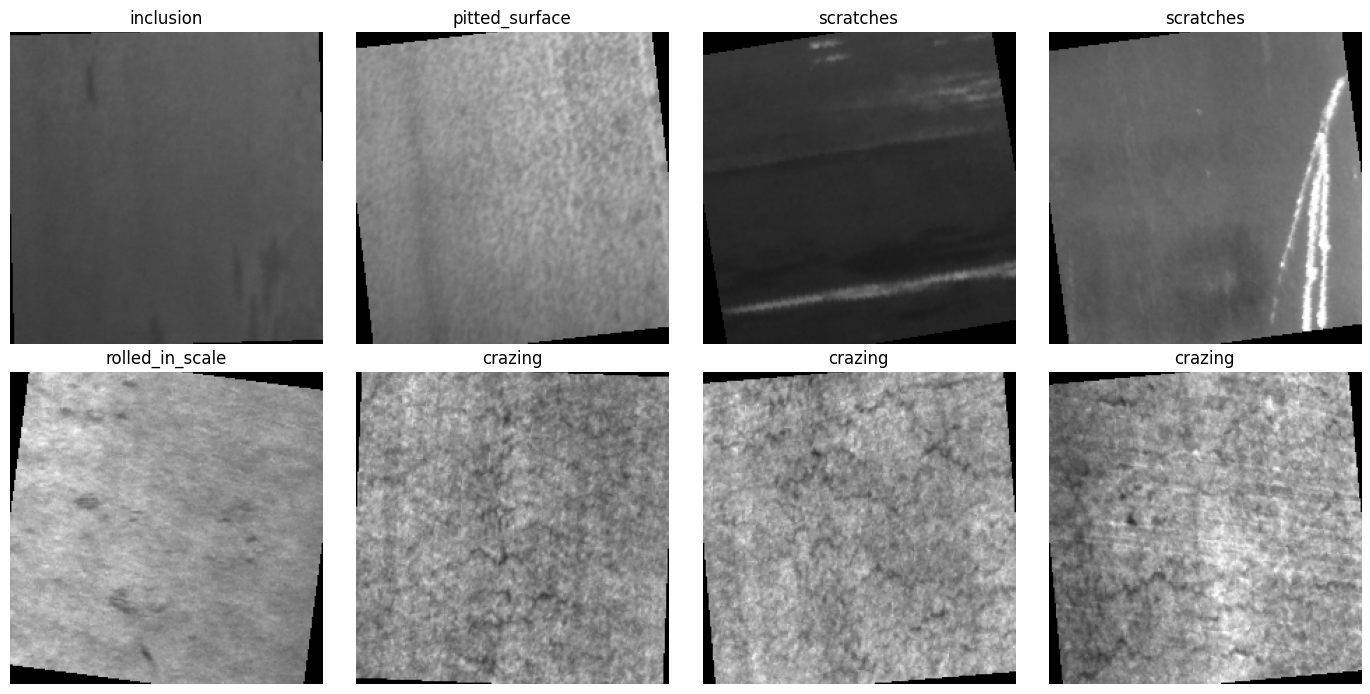

In [ ]:
def denormalize_image(image_tensor):
    image = image_tensor.numpy().transpose((1, 2, 0))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = std * image + mean
    image = np.clip(image, 0, 1)

    return image

images, labels = next(iter(train_loader))

plt.figure(figsize=(14, 7))

for index in range(8):
    plt.subplot(2, 4, index + 1)

    image = denormalize_image(images[index])
    plt.imshow(image)

    class_name = CLASS_NAMES[labels[index].item()]
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Load Pretrained MobileNetV2

A pretrained MobileNetV2 model is loaded. The pretrained weights contain features learned from the ImageNet dataset, allowing faster and more accurate learning compared to training a CNN from scratch.

In [ ]:
# Load pretrained MobileNetV2
weights = models.MobileNet_V2_Weights.DEFAULT

model = models.mobilenet_v2(weights=weights)

print("MobileNetV2 loaded successfully!")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 139MB/s]

MobileNetV2 loaded successfully!


In [ ]:
print(model)

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

Freeze the feature extractor

In [ ]:
for parameter in model.features.parameters():
    parameter.requires_grad = False

print("Feature extraction layers frozen.")

Feature extraction layers frozen.


Replace the last layer

In [ ]:
input_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    input_features,
    NUM_CLASSES
)

model = model.to(device)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=6, bias=True)
)


Verify the replacement

In [ ]:
print("Number of classes:", NUM_CLASSES)
print("Output neurons:", model.classifier[1].out_features)

Number of classes: 6
Output neurons: 6


Count trainable parameters

In [ ]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters      : {total_params:,}")
print(f"Trainable parameters  : {trainable_params:,}")

Total parameters      : 2,231,558
Trainable parameters  : 7,686


## Loss Function and Optimizer

CrossEntropyLoss is used for multi-class classification. The Adam optimizer updates only the trainable classifier parameters while the pretrained feature extractor remains frozen.

In [ ]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer (only updates the classifier)
optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


Training settings

In [ ]:
EPOCHS = 10

best_validation_accuracy = 0.0

train_losses = []
validation_losses = []

train_accuracies = []
validation_accuracies = []

print("Training settings created.")
print("Epochs:", EPOCHS)

Training settings created.
Epochs: 10


## Training Function

This function trains the MobileNetV2 model for one epoch and returns the average training loss and accuracy.

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer):
## model → MobileNetV2
## dataloader → Training images
## criterion → CrossEntropyLoss
## optimizer → Adam

    # Set model to training mode
    model.train()

    # Initialize variables
    running_loss = 0.0
    correct_predictions = 0
    total_images = 0

    # Loop through all training batches
    for images, labels in dataloader:

        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        # Add batch loss
        running_loss += loss.item()

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        # Count correct predictions
        total_images += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    # Calculate average loss and accuracy
    epoch_loss = running_loss / len(dataloader)
    epoch_accuracy = correct_predictions / total_images

    return epoch_loss, epoch_accuracy

## Validation Function

This function evaluates the model using the validation dataset. Model weights are not updated during validation.

In [ ]:
def validate_model(model, dataloader, criterion):

    # Set model to evaluation mode
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_images = 0

    # Disable gradient calculation
    with torch.no_grad():

        for images, labels in dataloader:

            # Move data to GPU
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Add batch loss
            running_loss += loss.item()

            # Get predicted class
            _, predicted = torch.max(outputs, 1)

            # Count correct predictions
            total_images += labels.size(0)
            correct_predictions += (
                predicted == labels
            ).sum().item()

    # Calculate average loss and accuracy
    epoch_loss = running_loss / len(dataloader)
    epoch_accuracy = correct_predictions / total_images

    return epoch_loss, epoch_accuracy

## Model Training

The model is trained for multiple epochs. After every epoch, training and validation performance are recorded. The best model is saved using validation accuracy.

In [ ]:
EPOCHS = 10

train_losses = []
validation_losses = []

train_accuracies = []
validation_accuracies = []

best_validation_accuracy = 0.0
best_model_weights = copy.deepcopy(model.state_dict())

start_time = time.time()

for epoch in range(EPOCHS):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    validation_loss, validation_accuracy = validate_model(
        model,
        validation_loader,
        criterion
    )

    train_losses.append(train_loss)
    validation_losses.append(validation_loss)

    train_accuracies.append(train_accuracy)
    validation_accuracies.append(validation_accuracy)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy * 100:.2f}% | "
        f"Validation Loss: {validation_loss:.4f} | "
        f"Validation Accuracy: {validation_accuracy * 100:.2f}%"
    )

    # Save the best model weights
    if validation_accuracy > best_validation_accuracy:

        best_validation_accuracy = validation_accuracy
        best_model_weights = copy.deepcopy(
            model.state_dict()
        )

training_time = time.time() - start_time

# Restore the best model
model.load_state_dict(best_model_weights)

print("\nTraining completed.")
print(
    f"Best validation accuracy: "
    f"{best_validation_accuracy * 100:.2f}%"
)
print(
    f"Total training time: "
    f"{training_time / 60:.2f} minutes"
)

Epoch 1/10 | Train Loss: 0.9936 | Train Accuracy: 81.03% | Validation Loss: 0.7466 | Validation Accuracy: 97.04%
Epoch 2/10 | Train Loss: 0.3617 | Train Accuracy: 96.83% | Validation Loss: 0.2534 | Validation Accuracy: 98.52%
Epoch 3/10 | Train Loss: 0.2557 | Train Accuracy: 95.87% | Validation Loss: 0.1623 | Validation Accuracy: 98.52%
Epoch 4/10 | Train Loss: 0.1767 | Train Accuracy: 97.62% | Validation Loss: 0.1140 | Validation Accuracy: 99.26%
Epoch 5/10 | Train Loss: 0.1411 | Train Accuracy: 97.46% | Validation Loss: 0.0987 | Validation Accuracy: 99.26%
Epoch 6/10 | Train Loss: 0.1336 | Train Accuracy: 97.30% | Validation Loss: 0.0920 | Validation Accuracy: 98.89%
Epoch 7/10 | Train Loss: 0.1153 | Train Accuracy: 98.02% | Validation Loss: 0.0741 | Validation Accuracy: 99.63%
Epoch 8/10 | Train Loss: 0.1044 | Train Accuracy: 97.78% | Validation Loss: 0.0670 | Validation Accuracy: 99.63%
Epoch 9/10 | Train Loss: 0.1042 | Train Accuracy: 97.70% | Validation Loss: 0.0662 | Validation 

Save the best model

In [ ]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS_DIR / "mobilenetv2_transfer_learning.pth"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": CLASS_NAMES,
        "num_classes": NUM_CLASSES,
        "image_size": IMAGE_SIZE,
        "best_validation_accuracy": best_validation_accuracy
    },
    MODEL_PATH
)

print("Model saved to:")
print(MODEL_PATH)

Model saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/models/mobilenetv2_transfer_learning.pth


Plot loss curves

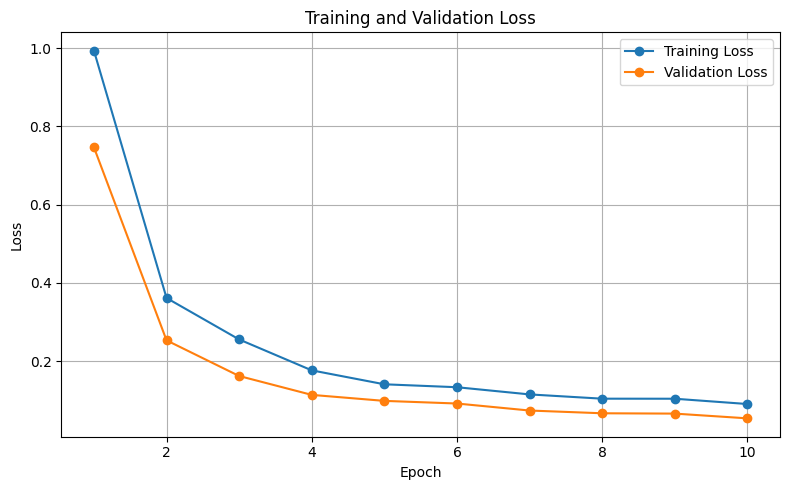

Loss graph saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/results/mobilenetv2_loss_curve.png


In [ ]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    validation_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_graph_path = (
    RESULTS_DIR / "mobilenetv2_loss_curve.png"
)

plt.savefig(loss_graph_path, dpi=300)
plt.show()

print("Loss graph saved to:")
print(loss_graph_path)

Plot accuracy curves

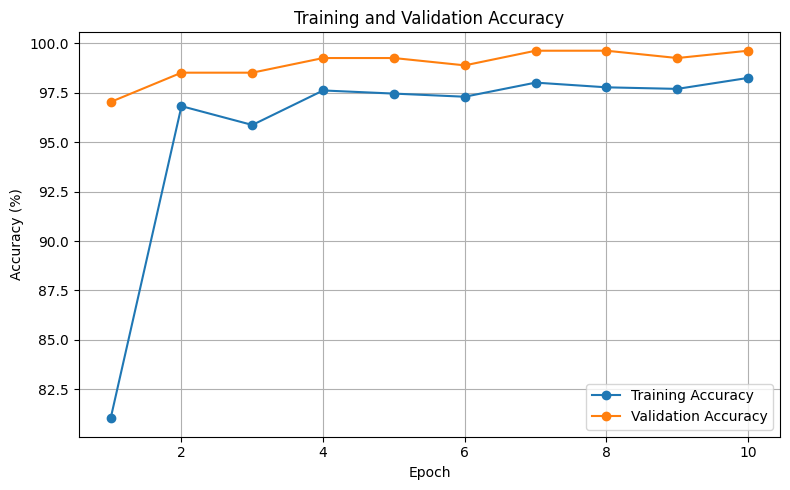

Accuracy graph saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/results/mobilenetv2_accuracy_curve.png


In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    [accuracy * 100 for accuracy in train_accuracies],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    [
        accuracy * 100
        for accuracy in validation_accuracies
    ],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

accuracy_graph_path = (
    RESULTS_DIR / "mobilenetv2_accuracy_curve.png"
)

plt.savefig(accuracy_graph_path, dpi=300)
plt.show()

print("Accuracy graph saved to:")
print(accuracy_graph_path)

## Test Set Evaluation

The best-performing MobileNetV2 model is evaluated using the untouched test dataset.

In [ ]:
def evaluate_test_set(model, dataloader):

    # Set model to evaluation mode
    model.eval()

    all_labels = []
    all_predictions = []
    all_confidences = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            # Get model outputs
            outputs = model(images)

            # Convert outputs into probabilities
            probabilities = torch.softmax(outputs, dim=1)

            # Get confidence and predicted class
            confidence, predicted = torch.max(
                probabilities,
                dim=1
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predicted.cpu().numpy()
            )

            all_confidences.extend(
                confidence.cpu().numpy()
            )

    return (
        np.array(all_labels),
        np.array(all_predictions),
        np.array(all_confidences)
    )

In [ ]:
true_labels, predicted_labels, confidence_scores = (
    evaluate_test_set(model, test_loader)
)

print("Number of test predictions:", len(predicted_labels))

Number of test predictions: 270


Calculate evaluation metrics

In [ ]:
test_accuracy = accuracy_score(
    true_labels,
    predicted_labels
)

test_precision = precision_score(
    true_labels,
    predicted_labels,
    average="macro",
    zero_division=0
)

test_recall = recall_score(
    true_labels,
    predicted_labels,
    average="macro",
    zero_division=0
)

test_f1 = f1_score(
    true_labels,
    predicted_labels,
    average="macro",
    zero_division=0
)

print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Macro Precision: {test_precision * 100:.2f}%")
print(f"Macro Recall   : {test_recall * 100:.2f}%")
print(f"Macro F1-Score : {test_f1 * 100:.2f}%")

Test Accuracy : 99.63%
Macro Precision: 99.64%
Macro Recall   : 99.63%
Macro F1-Score : 99.63%


Generate the classification report

In [ ]:
report = classification_report(
    true_labels,
    predicted_labels,
    target_names=CLASS_NAMES,
    zero_division=0
)

print(report)

                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        45
      inclusion       0.98      1.00      0.99        45
        patches       1.00      1.00      1.00        45
 pitted_surface       1.00      1.00      1.00        45
rolled_in_scale       1.00      1.00      1.00        45
      scratches       1.00      0.98      0.99        45

       accuracy                           1.00       270
      macro avg       1.00      1.00      1.00       270
   weighted avg       1.00      1.00      1.00       270



In [ ]:
report_path = RESULTS_DIR / "mobilenetv2_classification_report.txt"

with open(report_path, "w") as file:
    file.write(report)

print("Classification report saved to:")
print(report_path)

Classification report saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/results/mobilenetv2_classification_report.txt


Save the overall metrics

In [ ]:
metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-Score",
        "Best Validation Accuracy"
    ],
    "Value": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        best_validation_accuracy
    ]
})

metrics_path = RESULTS_DIR / "mobilenetv2_metrics.csv"

metrics_df.to_csv(metrics_path, index=False)

display(metrics_df)

print("Metrics saved to:")
print(metrics_path)

,Metric,Value
0,Accuracy,0.996296
1,Macro Precision,0.996377
2,Macro Recall,0.996296
3,Macro F1-Score,0.996296
4,Best Validation Accuracy,0.996296


Metrics saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/results/mobilenetv2_metrics.csv


Create the confusion matrix

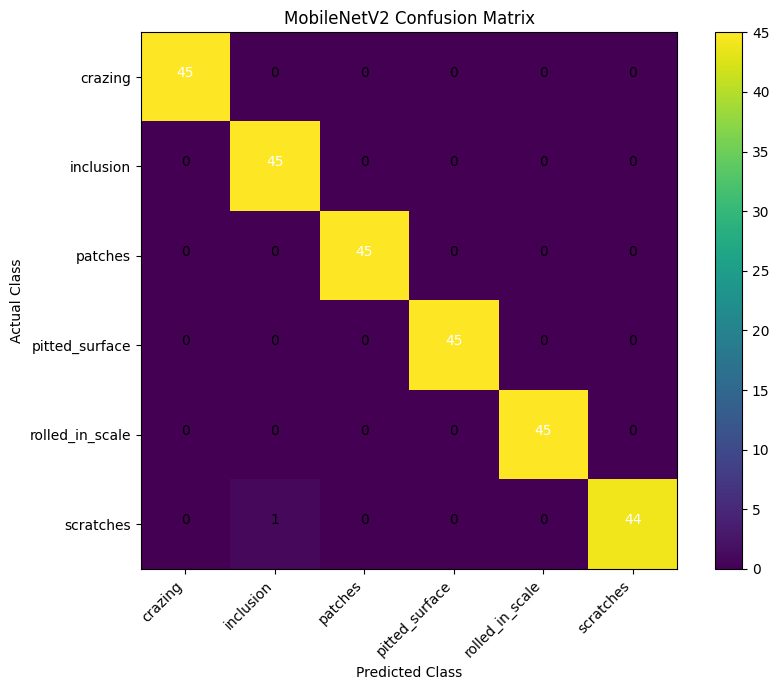

Confusion matrix saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/results/mobilenetv2_confusion_matrix.png


In [ ]:
confusion = confusion_matrix(
    true_labels,
    predicted_labels
)

plt.figure(figsize=(9, 7))

plt.imshow(confusion, interpolation="nearest")
plt.title("MobileNetV2 Confusion Matrix")
plt.colorbar()

tick_positions = np.arange(len(CLASS_NAMES))

plt.xticks(
    tick_positions,
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

plt.yticks(
    tick_positions,
    CLASS_NAMES
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

threshold = confusion.max() / 2

for row in range(confusion.shape[0]):
    for column in range(confusion.shape[1]):

        plt.text(
            column,
            row,
            str(confusion[row, column]),
            horizontalalignment="center",
            color=(
                "white"
                if confusion[row, column] > threshold
                else "black"
            )
        )

plt.tight_layout()

confusion_path = (
    RESULTS_DIR / "mobilenetv2_confusion_matrix.png"
)

plt.savefig(
    confusion_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved to:")
print(confusion_path)

Display qualitative results

In [ ]:
def show_predictions(
    model,
    dataset,
    class_names,
    number_of_images=8
):

    model.eval()

    selected_indices = random.sample(
        range(len(dataset)),
        number_of_images
    )

    plt.figure(figsize=(14, 8))

    with torch.no_grad():

        for position, dataset_index in enumerate(
            selected_indices
        ):

            image, actual_label = dataset[dataset_index]

            input_image = image.unsqueeze(0).to(device)

            output = model(input_image)

            probabilities = torch.softmax(output, dim=1)

            confidence, predicted_label = torch.max(
                probabilities,
                dim=1
            )

            displayed_image = denormalize_image(image)

            plt.subplot(2, 4, position + 1)
            plt.imshow(displayed_image)

            actual_name = class_names[actual_label]

            predicted_name = class_names[
                predicted_label.item()
            ]

            confidence_percentage = (
                confidence.item() * 100
            )

            plt.title(
                f"Actual: {actual_name}\n"
                f"Predicted: {predicted_name}\n"
                f"Confidence: {confidence_percentage:.1f}%"
            )

            plt.axis("off")

    plt.tight_layout()

    qualitative_path = (
        RESULTS_DIR / "mobilenetv2_qualitative_results.png"
    )

    plt.savefig(
        qualitative_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Qualitative results saved to:")
    print(qualitative_path)

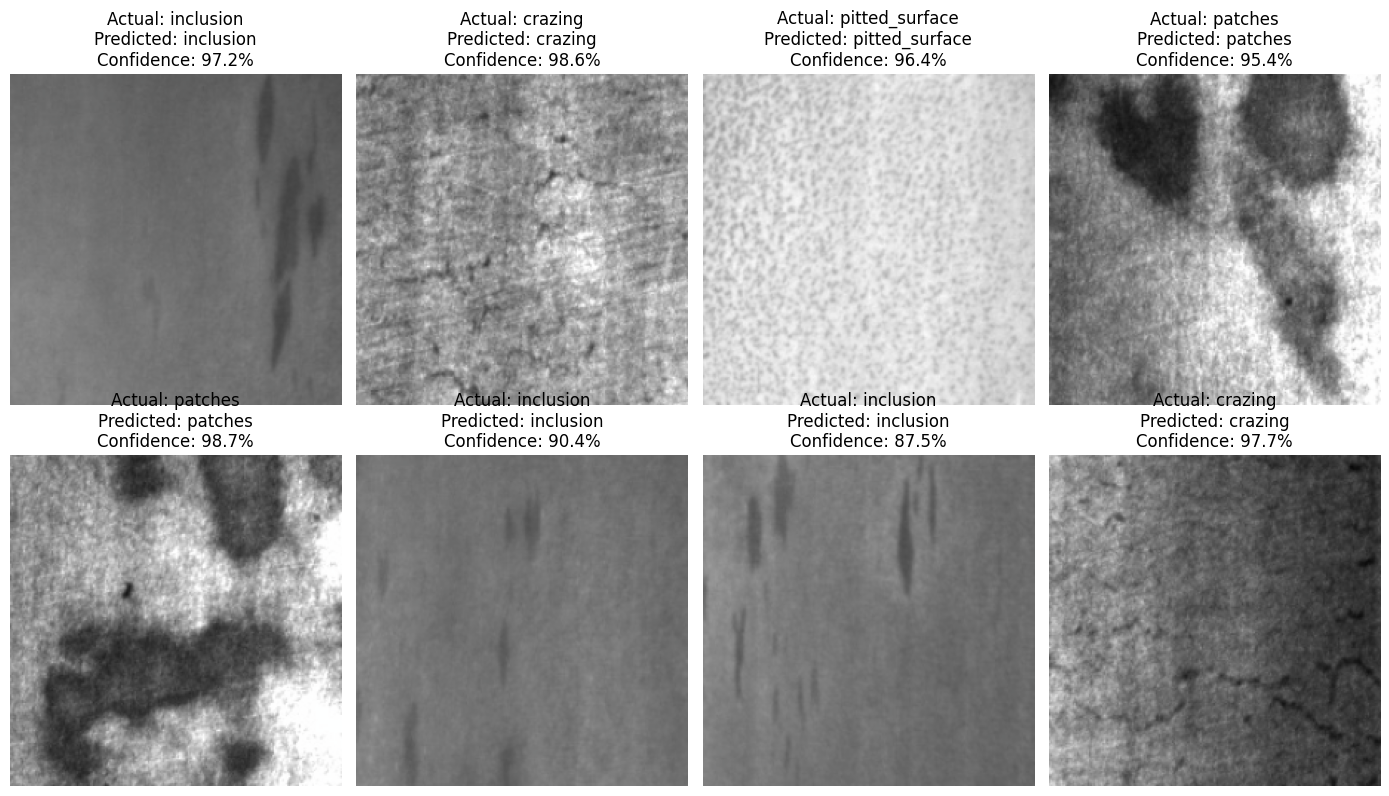

Qualitative results saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/results/mobilenetv2_qualitative_results.png


In [ ]:
show_predictions(
    model,
    test_dataset,
    CLASS_NAMES,
    number_of_images=8
)

Find failure cases

In [ ]:
incorrect_indices = np.where(
    true_labels != predicted_labels
)[0]

print("Total incorrect predictions:", len(incorrect_indices))
print(
    f"Error rate: "
    f"{len(incorrect_indices) / len(true_labels) * 100:.2f}%"
)

Total incorrect predictions: 1
Error rate: 0.37%


In [ ]:
def show_failure_cases(
    dataset,
    true_labels,
    predicted_labels,
    confidence_scores,
    class_names,
    maximum_images=8
):

    incorrect_indices = np.where(
        true_labels != predicted_labels
    )[0]

    if len(incorrect_indices) == 0:
        print("No incorrect predictions were found.")
        return

    number_to_show = min(
        maximum_images,
        len(incorrect_indices)
    )

    selected_indices = incorrect_indices[:number_to_show]

    plt.figure(figsize=(14, 8))

    for position, dataset_index in enumerate(
        selected_indices
    ):

        image, _ = dataset[dataset_index]

        displayed_image = denormalize_image(image)

        actual_name = class_names[
            true_labels[dataset_index]
        ]

        predicted_name = class_names[
            predicted_labels[dataset_index]
        ]

        confidence = (
            confidence_scores[dataset_index] * 100
        )

        plt.subplot(2, 4, position + 1)
        plt.imshow(displayed_image)

        plt.title(
            f"Actual: {actual_name}\n"
            f"Predicted: {predicted_name}\n"
            f"Confidence: {confidence:.1f}%"
        )

        plt.axis("off")

    plt.tight_layout()

    failure_path = (
        RESULTS_DIR / "mobilenetv2_failure_cases.png"
    )

    plt.savefig(
        failure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Failure cases saved to:")
    print(failure_path)


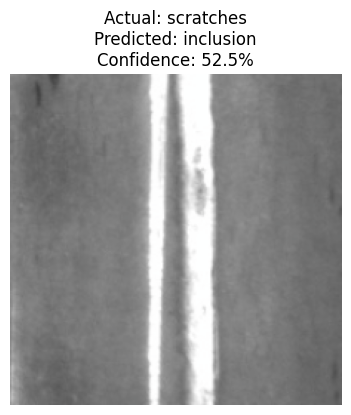

Failure cases saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/results/mobilenetv2_failure_cases.png


In [ ]:
    show_failure_cases(
    test_dataset,
    true_labels,
    predicted_labels,
    confidence_scores,
    CLASS_NAMES
)

Save all individual predictions

In [ ]:
predictions_df = pd.DataFrame({
    "Actual Class": [
        CLASS_NAMES[label]
        for label in true_labels
    ],
    "Predicted Class": [
        CLASS_NAMES[label]
        for label in predicted_labels
    ],
    "Confidence": confidence_scores,
    "Correct": true_labels == predicted_labels
})

predictions_path = (
    RESULTS_DIR / "mobilenetv2_test_predictions.csv"
)

predictions_df.to_csv(
    predictions_path,
    index=False
)

display(predictions_df.head())

print("Predictions saved to:")
print(predictions_path)

,Actual Class,Predicted Class,Confidence,Correct
0,crazing,crazing,0.943873,True
1,crazing,crazing,0.959460,True
2,crazing,crazing,0.954205,True
3,crazing,crazing,0.983249,True
4,crazing,crazing,0.927378,True


Predictions saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/results/mobilenetv2_test_predictions.csv


## Observations

- Training and validation accuracy improved during training.
- The validation accuracy remained close to the training accuracy, indicating limited overfitting.
- Some defect classes were easier to identify than others.
- Most incorrect predictions occurred between visually similar surface textures.
- Some wrong predictions had high confidence, showing that further fine-tuning is required.

## MobileNetV2 Results

The MobileNetV2 transfer-learning model was evaluated on the common test set.

### Test Performance
- Accuracy: 99.63%
- Macro Precision: 99.64%
- Macro Recall: 99.63%
- Macro F1-Score: 99.63%

Out of 270 test images, 269 were classified correctly.

The only observed error was a `scratches` image classified as `inclusion`.

The results indicate that transfer learning provides a substantial improvement over the custom CNN baseline.